# Tech Stock Analysis and Prediction
## Naive Baseline Model

**Goal:** Establish the simplest possible baseline by assuming tomorrow's return will equal today's return (persistence assumption). This serves as the minimum performance threshold that all subsequent machine learning models must outperform to justify their added complexity.

**Approach:** Predict each test day's return using the previous day's actual return — no feature engineering, no training, just pure persistence.

**Input:** Cleaned NVDA returns data
**Output:** Baseline performance metrics to benchmark Linear Regression, Random Forest, and XGBoost against


In [1]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import warnings
warnings.filterwarnings("ignore")

c:\Users\LENOVO\anaconda3\lib\site-packages\pandas\core\arrays\masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (



# Loading Data

Loading the cleaned NVDA dataset containing daily stock prices and returns from 2018-2025.

## Splitting Data

Performing a chronological 80/20 split. For the naive baseline, we only need the Returns column—no feature engineering required.

In [2]:
nvda_simple=nvda[["date","Returns"]].copy()
split=int(len(nvda_simple)*0.8)

train = nvda_simple.iloc[:split]
test = nvda_simple.iloc[split:]

y_train = train['Returns']
y_test = test['Returns']

print(f"Train: {len(y_train)} samples")
print(f"Test: {len(y_test)} samples")

NameError: name 'nvda' is not defined

# Naive Prediction

Using yesterday's return to predict today's return (persistence assumption). The first test sample has no "yesterday," so we drop it, leaving 397 predictions.

In [ ]:
y_pred = y_test.shift(1)

y_pred = y_pred.dropna()
y_test_aligned = y_test.iloc[1:]

print(f"Predictions: {len(y_pred)} samples")
print(f"Aligned test: {len(y_test_aligned)} samples")

Predictions: 397 samples
Aligned test: 397 samples


## Metrics Evaluation

Calculating regression metrics to quantify how poorly the naive approach performs compared to the mean baseline.

In [ ]:
mse = mean_squared_error(y_test_aligned, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test_aligned, y_pred)
r2 = r2_score(y_test_aligned, y_pred)
print("NAIVE BASELINE PERFORMANCE \n")
print(f"MSE:   {mse:.6f}")
print(f"RMSE:  {rmse:.6f}")
print(f"MAE:   {mae:.6f}")
print(f"R²:    {r2:.4f}")

NAIVE BASELINE PERFORMANCE 

MSE:   0.002304
RMSE:  0.047996
MAE:   0.034369
R²:    -1.2744


## Actual vs Predicted Plot

Visualizing the first 100 test samples to clearly show how naive predictions lag one step behind actual returns—they're always "predicting" what already happened.

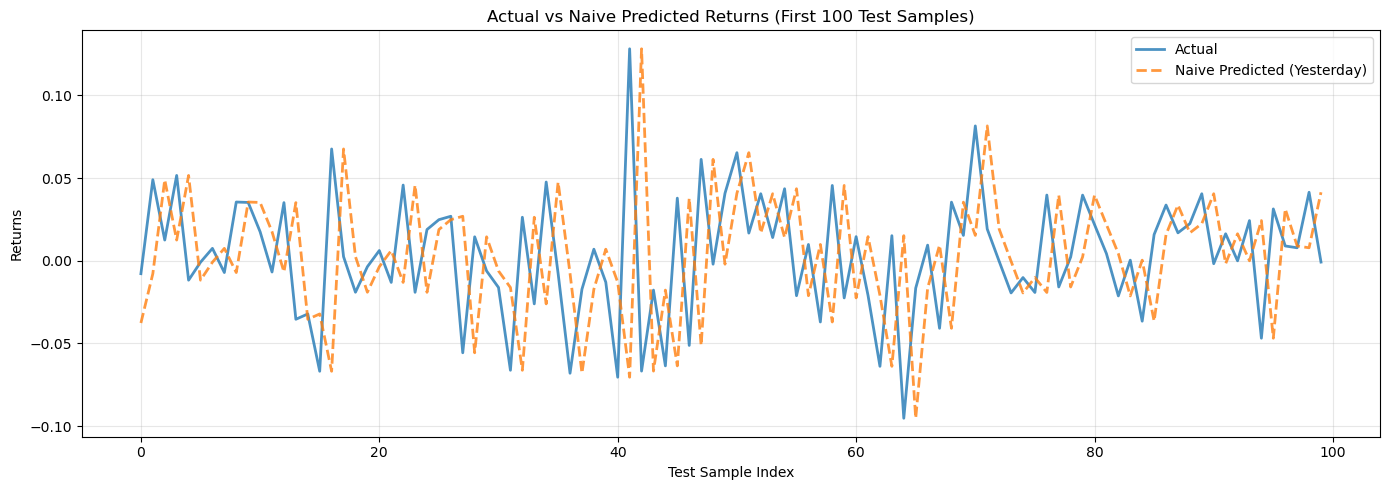

In [ ]:

plt.figure(figsize=(14, 5))
plt.plot(y_test_aligned.values[:100], label='Actual', alpha=0.8, linewidth=2)
plt.plot(y_pred.values[:100], label='Naive Predicted (Yesterday)', alpha=0.8, linewidth=2, linestyle='--')
plt.title('Actual vs Naive Predicted Returns (First 100 Test Samples)')
plt.xlabel('Test Sample Index')
plt.ylabel('Returns')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Naive Baseline — Results Summary

**Model Performance:**
- MSE: 0.002304
- RMSE: 0.047996
- MAE: 0.034369
- R² Score: -1.2744

**Key Observations:**
- The naive baseline (persistence model) assumes tomorrow's return equals today's return
- **Highly negative R²** (-1.27) indicates this approach performs significantly worse than simply predicting the mean return
- The prediction line visibly **lags one step behind** actual returns, as it can only "predict" what already happened
- Average prediction error (MAE) is 3.44%, establishing the performance floor for subsequent models

**Baseline Purpose:**
This establishes the minimum performance threshold. Any machine learning model that cannot outperform this trivial "repeat yesterday" strategy would not justify its complexity. The naive baseline serves as a reality check for all subsequent models.